# Employee Attrition Prediction using Machine Learning

This project aims to predict employee attrition and identify key factors influencing employee turnover using machine learning techniques.

We use Logistic Regression and Random Forest models along with exploratory data analysis to derive actionable HR insights.

In [3]:
# STEP 0: UPLOAD DATASET
# ==============================
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [4]:
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# STEP 2: LOAD DATA
# ==============================
# Ensure the filename matches what you uploaded in Colab
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


## Data Cleaning

In this step, we check for missing values and remove irrelevant columns that do not contribute to prediction.
This ensures the dataset is clean and ready for analysis.


In [5]:
# ==============================
# STEP 3: DATA CLEANING
# ==============================
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Drop irrelevant columns
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Keep original copy for EDA
df_original = df.copy()

Shape: (1470, 35)

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Year

## Data Encoding

Machine learning models require numerical input.
We convert categorical variables using:
- Label Encoding for ordinal features
- One-Hot Encoding for nominal features

In [6]:
# ==============================
# STEP 4: ENCODING
# ==============================
# Label Encoding for ordinal column
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
if 'BusinessTravel' in df.columns:
    df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

# One-Hot Encoding for nominal columns
df = pd.get_dummies(df, drop_first=True)

## Exploratory Data Analysis (EDA)

We analyze patterns in the data to understand factors influencing employee attrition.
This includes visualizing relationships between features and the target variable.

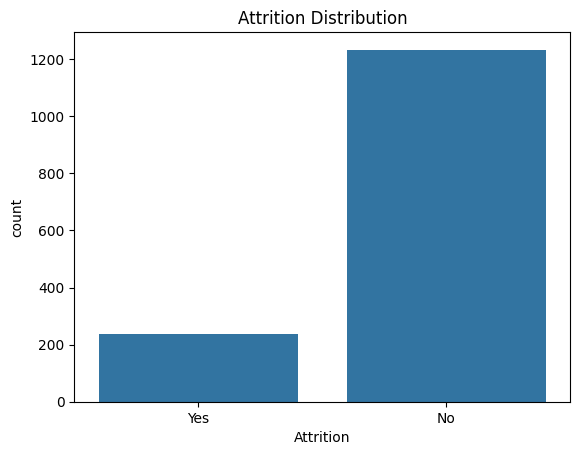

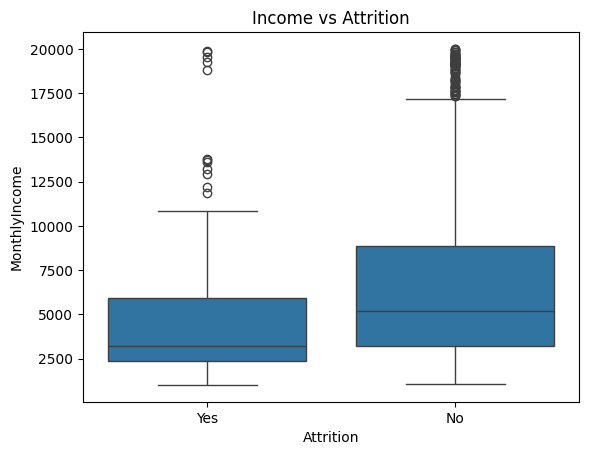

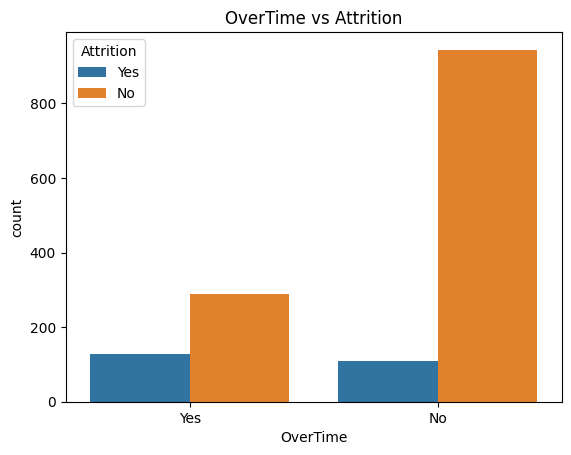

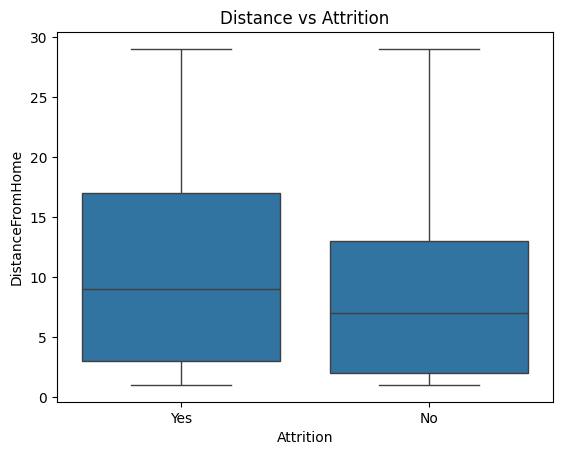

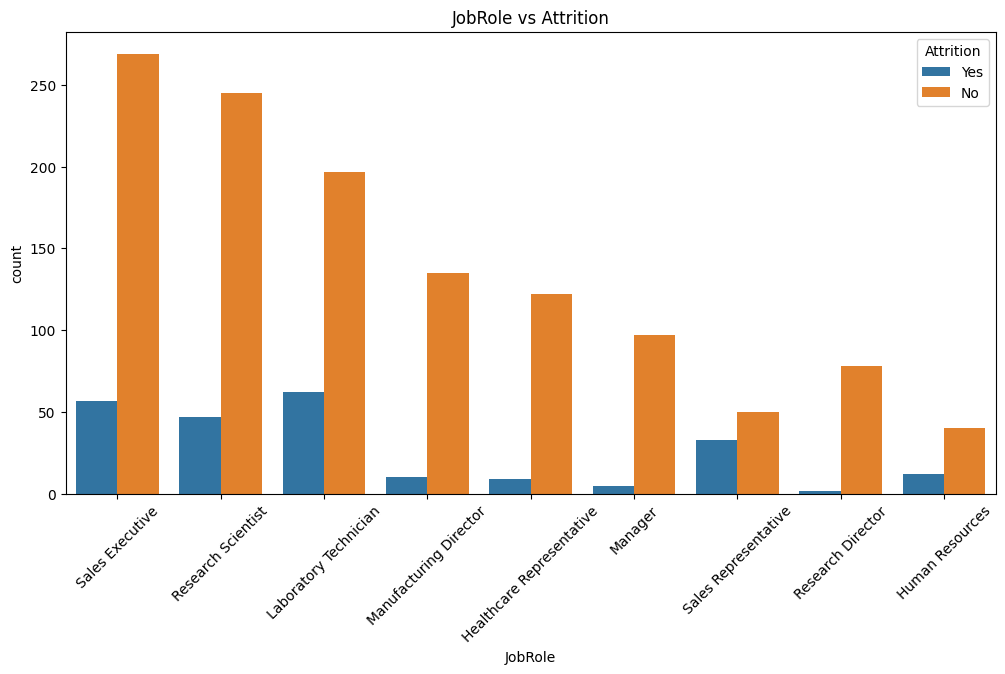

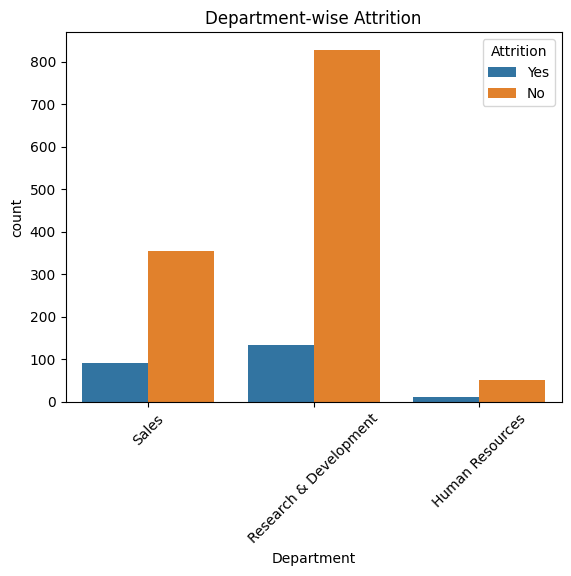

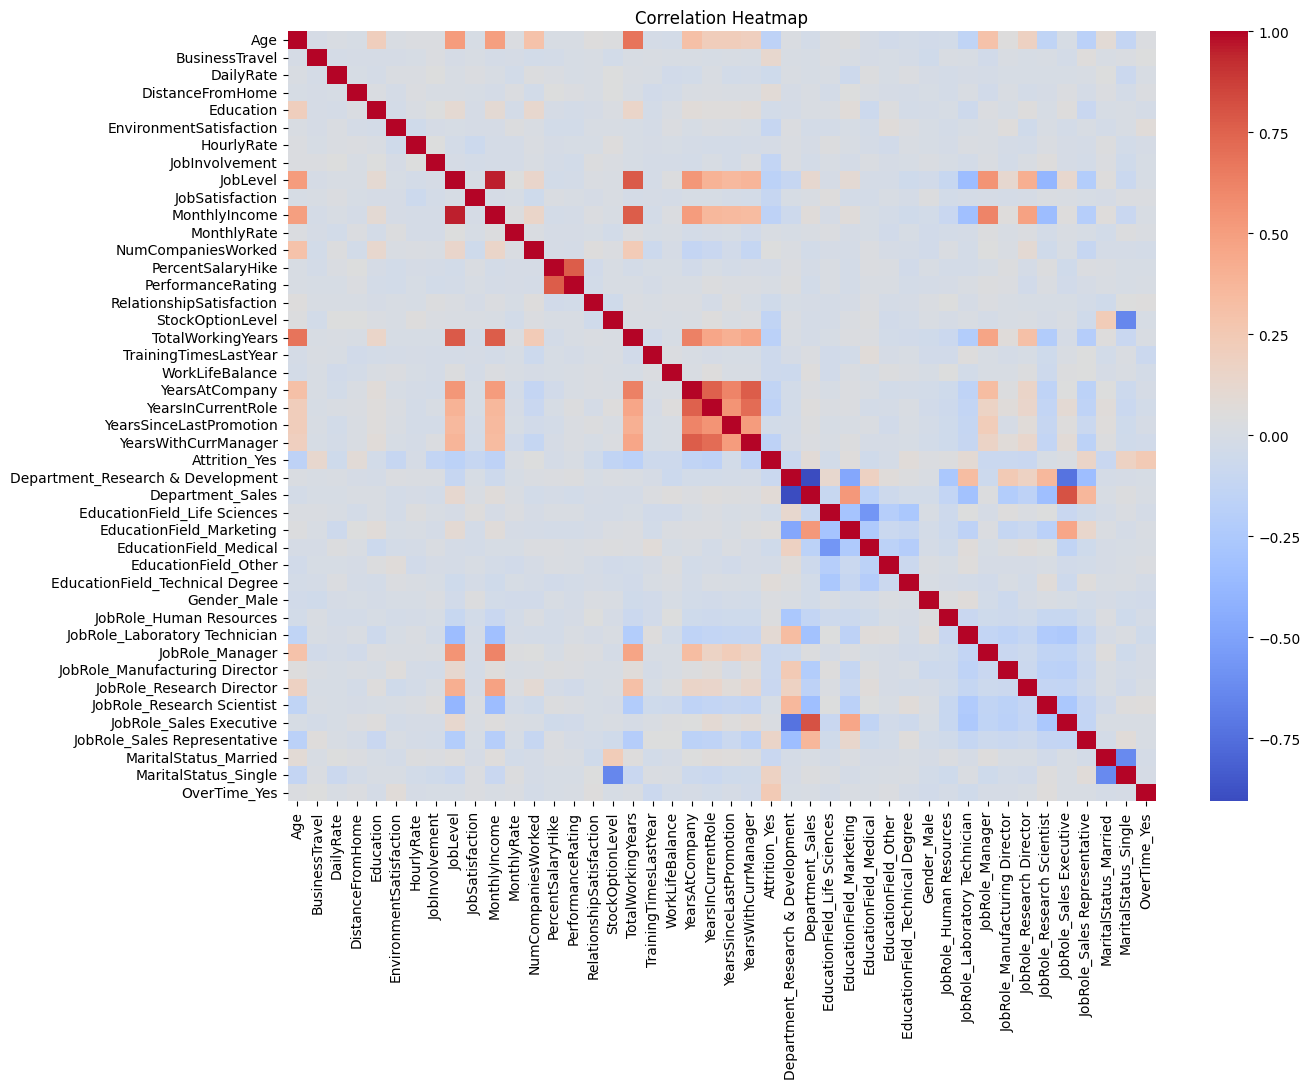

In [10]:
# ==============================
# STEP 5: EDA
# ==============================
# Attrition Distribution
sns.countplot(x='Attrition', data=df_original)
plt.title("Attrition Distribution")
plt.show()

# Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_original)
plt.title("Income vs Attrition")
plt.show()

# OverTime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df_original)
plt.title("OverTime vs Attrition")
plt.show()

# DistanceFromHome vs Attrition
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df_original)
plt.title("Distance vs Attrition")
plt.show()

# JobRole vs Attrition
plt.figure(figsize=(12,6))
sns.countplot(x='JobRole', hue='Attrition', data=df_original)
plt.xticks(rotation=45)
plt.title("JobRole vs Attrition")
plt.show()

# Department vs Attrition (REQUIRED)
sns.countplot(x='Department', hue='Attrition', data=df_original)
plt.xticks(rotation=45)
plt.title("Department-wise Attrition")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



## Model Building

We split the dataset into training and testing sets and train two models:
- Logistic Regression (for interpretability)
- Random Forest (for capturing complex relationships)

In [11]:
# ==============================
# STEP 6: SPLIT DATA
# ==============================
X = df.drop('Attrition_Yes', axis=1)
y = df['Attrition_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# STEP 7: SCALING
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# STEP 8: LOGISTIC REGRESSION
# ==============================
lr = LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear', random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# ==============================
# STEP 9: RANDOM FOREST
# ==============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression Results
Accuracy: 0.717687074829932
              precision    recall  f1-score   support

       False       0.92      0.74      0.82       255
        True       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.72      0.76       294


Random Forest Results
Accuracy: 0.8469387755102041
              precision    recall  f1-score   support

       False       0.89      0.94      0.91       255
        True       0.38      0.23      0.29        39

    accuracy                           0.85       294
   macro avg       0.63      0.59      0.60       294
weighted avg       0.82      0.85      0.83       294



## Feature Importance

We analyze which features have the highest impact on employee attrition.
This helps identify key drivers of employee turnover.

In [12]:
# ==============================
# STEP 10: FEATURE IMPORTANCE
# ==============================
# Logistic Regression Importance
feat_lr = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("\nTop Features (Logistic Regression):")
print(feat_lr.head(10))

# Random Forest Importance
feat_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features (Random Forest):")
print(feat_rf.head(10))


Top Features (Logistic Regression):
                          Feature  Importance
20                 YearsAtCompany    0.968897
42                   OverTime_Yes    0.928898
33  JobRole_Laboratory Technician    0.900089
41           MaritalStatus_Single    0.760177
21             YearsInCurrentRole    0.716848
39   JobRole_Sales Representative    0.641206
25               Department_Sales    0.634605
23           YearsWithCurrManager    0.558938
32        JobRole_Human Resources    0.547276
37     JobRole_Research Scientist    0.540054

Top Features (Random Forest):
                 Feature  Importance
42          OverTime_Yes    0.103412
10         MonthlyIncome    0.083541
16      StockOptionLevel    0.058413
0                    Age    0.057827
17     TotalWorkingYears    0.049345
20        YearsAtCompany    0.047114
8               JobLevel    0.041780
2              DailyRate    0.040432
21    YearsInCurrentRole    0.039406
23  YearsWithCurrManager    0.037877


## Risk Profiling

We calculate the probability of attrition and identify high-risk employees.
Employees with probability greater than 0.6 are considered at high risk.

In [13]:
# ==============================
# STEP 11: RISK PROFILING
# ==============================
df_test = X_test.copy()
df_test['Actual'] = y_test
df_test['Predicted'] = y_pred_lr

# Probability prediction (scaled data)
df_test['Probability'] = lr.predict_proba(X_test_scaled)[:,1]

# Threshold selection (balanced precision-recall)
high_risk = df_test[df_test['Probability'] > 0.6].sort_values(by='Probability', ascending=False)

print("\nHigh Risk Employees (Top):")
print(high_risk[['Actual', 'Predicted', 'Probability']].head())


High Risk Employees (Top):
      Actual  Predicted  Probability
1057    True       True     0.987505
51      True       True     0.969560
946     True       True     0.958702
1168   False       True     0.956639
111     True       True     0.945422


## Department-wise Analysis

We analyze attrition across departments to identify which departments have higher employee turnover.

In [14]:
# ==============================
# STEP 12: DEPARTMENT ANALYSIS TABLE
# ==============================
dept_analysis = pd.crosstab(df_original['Department'], df_original['Attrition'])
print("\nDepartment vs Attrition Table:")
print(dept_analysis)


Department vs Attrition Table:
Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [15]:
# ==============================
# STEP 13: SAVE MODEL + SCALER
# ==============================
joblib.dump(lr, "attrition_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully.")


Model and scaler saved successfully.


## Conclusion

Logistic Regression performed better in identifying employees at risk of leaving.
Key factors influencing attrition include overtime, job satisfaction, and department.

These insights can help HR teams take proactive actions to reduce employee turnover.